Initialisation du modèle...
Poids chargés avec succès !

Position de départ :


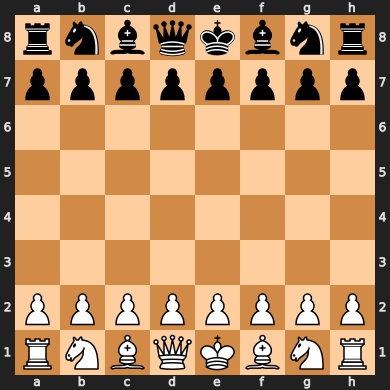


Recherche du meilleur coup en cours...
Meilleur coup trouvé : d2d4 (Score: 56.371)
Recherche terminée en 0.71 secondes.

Nouvelle position :


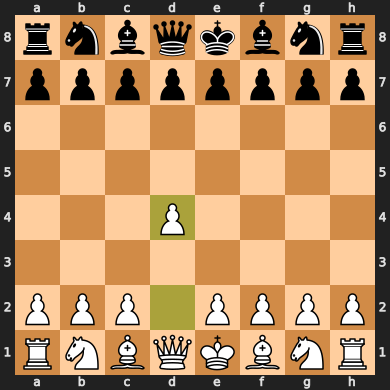

Stockfish suggère : c7c6

Position après le coup de Stockfish :


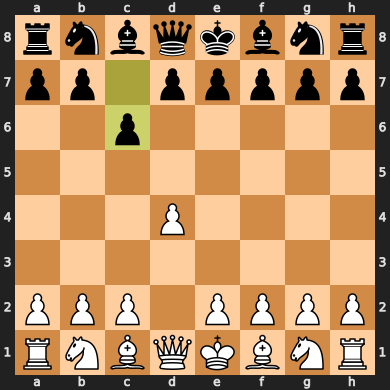


Position de départ :


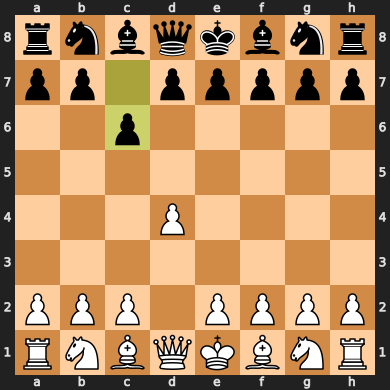


Recherche du meilleur coup en cours...


KeyboardInterrupt: 

In [1]:
import chess
import torch
import torch.nn as nn
import time

from stockfish import Stockfish
stockfish = Stockfish(path="C:/Users/yount/Downloads/stockfish-windows-x86-64-avx2/stockfish/stockfish-windows-x86-64-avx2.exe")
stockfish.set_elo_rating(2000)
# ==========================================
# 1. DÉFINITION DU MODÈLE PYTORCH
# ==========================================
class CReLU(nn.Module):
    def __init__(self, clip_value=255.0):
        super().__init__()
        self.clip_value = clip_value

    def forward(self, x):
        return torch.clamp(x, min=0.0, max=self.clip_value)

class ChessNNUE(nn.Module):
    def __init__(self):
        super().__init__()
        self.feature_transformer = nn.Embedding(40961, 768)
        
        # On remplace tous les nn.ReLU() par CReLU(255.0)
        self.linear_stack = nn.Sequential(
            nn.Linear(1536, 512),
            CReLU(),
            nn.Linear(512, 32),
            CReLU(),
            nn.Linear(32, 32),
            CReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, us_indices, them_indices):
        # 1. On somme les poids (Accumulateur)
        us_acc = self.feature_transformer(us_indices).sum(dim=1)
        them_acc = self.feature_transformer(them_indices).sum(dim=1)
        
        # 2. TRÈS IMPORTANT : Le clamp de l'accumulateur (CReLU)
        us_acc = torch.clamp(us_acc, 0.0, 255.0)
        them_acc = torch.clamp(them_acc, 0.0, 255.0)
        
        combined = torch.cat([us_acc, them_acc], dim=1)
        out = self.linear_stack(combined)
        return out

# ==========================================
# 2. EXTRACTION DES FEATURES (HalfKP)
# ==========================================
def get_halfkp_indices(board: chess.Board, pov_color: chess.Color):
    """
    Traduit l'échiquier en indices HalfKP selon la perspective d'une couleur.
    """
    king_sq = board.king(pov_color)
    if pov_color == chess.BLACK:
        king_sq ^= 56 # Flip board pour le roi noir

    indices = []
    for sq in chess.SQUARES:
        piece = board.piece_at(sq)
        # On ignore les cases vides et les Rois (qui sont déjà encodés par king_sq)
        if piece is None or piece.piece_type == chess.KING:
            continue
            
        # Calcul de l'index de la pièce (0-4 pour nous, 5-9 pour l'adversaire)
        # python-chess: PAWN=1, KNIGHT=2, BISHOP=3, ROOK=4, QUEEN=5
        pc_idx = piece.piece_type - 1 
        if piece.color != pov_color:
            pc_idx += 5
            
        # Orientation de la case
        p_sq = sq
        if pov_color == chess.BLACK:
            p_sq ^= 56
            
        # Formule HalfKP classique : (Roi * 640) + (Piece * 64) + Case
        idx = king_sq * 640 + pc_idx * 64 + p_sq
        indices.append(idx)
        
    return indices

def evaluate_board(board: chess.Board, model: nn.Module) -> float:
    """
    Évalue la position du point de vue du joueur qui doit jouer.
    """
    # Récupération des indices pour les deux camps
    us_color = board.turn
    them_color = not us_color
    
    us_indices = get_halfkp_indices(board, us_color)
    them_indices = get_halfkp_indices(board, them_color)
    
    # Conversion en tenseurs (batch_size = 1)
    us_tensor = torch.tensor([us_indices], dtype=torch.long)
    them_tensor = torch.tensor([them_indices], dtype=torch.long)
    
    # Mode évaluation (désactive les gradients pour la vitesse)
    model.eval()
    with torch.no_grad():
        score = model(us_tensor, them_tensor)
        
    return score.item()

# ==========================================
# 3. RECHERCHE ET TRI DE COUPS
# ==========================================
def order_moves(board: chess.Board):
    """Trie les coups possibles pour optimiser l'élagage alpha-beta (captures en premier)."""
    moves = list(board.legal_moves)
    moves.sort(key=lambda m: board.is_capture(m), reverse=True)
    return moves

def quiesce(board: chess.Board, model: nn.Module, alpha: float, beta: float) -> float:
    """
    Recherche de quiescence: évaluer seulement les captures 
    jusqu'à une position calme pour éviter l'effet d'horizon.
    """
    stand_pat = evaluate_board(board, model)
    if stand_pat >= beta:
        return beta
    if alpha < stand_pat:
        alpha = stand_pat
        
    for move in order_moves(board):
        if board.is_capture(move):
            board.push(move)
            score = -quiesce(board, model, -beta, -alpha)
            board.pop()
            
            if score >= beta:
                return beta
            if score > alpha:
                alpha = score
    return alpha

def negamax(board: chess.Board, depth: int, model: nn.Module, alpha: float, beta: float) -> float:
    if depth == 0:
        return quiesce(board, model, alpha, beta)
        
    if board.is_game_over():
        if board.is_checkmate():
            return -100000.0 # Pire score si on est mat
        return 0.0 # Nul (pat, répétition, etc.)

    best_value = -float('inf')
    
    for move in order_moves(board):
        board.push(move)
        score = -negamax(board, depth - 1, model, -beta, -alpha)
        board.pop()
        
        best_value = max(best_value, score)
        alpha = max(alpha, score)
        if alpha >= beta:
            break # Coupure alpha-beta
            
    return best_value

def get_best_move(board: chess.Board, depth: int, model: nn.Module) -> chess.Move:
    best_move = None
    best_value = -float('inf')
    alpha = -float('inf')
    beta = float('inf')
    
    for move in order_moves(board):
        board.push(move)
        score = -negamax(board, depth - 1, model, -beta, -alpha)
        board.pop()
        
        if score > best_value:
            best_value = score
            best_move = move
            
        alpha = max(alpha, score)
        
    print(f"Meilleur coup trouvé : {best_move} (Score: {best_value:.3f})")
    return best_move

# ==========================================
# 4. SCRIPT PRINCIPAL
# ==========================================
if __name__ == "__main__":
    # 1. Initialiser le modèle
    print("Initialisation du modèle...")
    model = ChessNNUE()
    
    # 2. Charger les poids de manière robuste (gestion du '_orig_mod.')
    model_path = "../weights/weights1/model_weights_9.pth" # REMPLACE PAR LE NOM DE TON FICHIER
    try:
        state_dict = torch.load(model_path, map_location=torch.device('cpu'))
        
        clean_state_dict = {}
        for key, value in state_dict.items():
            clean_key = key.replace("_orig_mod.", "")
            clean_state_dict[clean_key] = value
            
        model.load_state_dict(clean_state_dict)
        print("Poids chargés avec succès !")
    except Exception as e:
        print(f"Attention, erreur lors du chargement des poids : {e}")
        print("Le script va continuer avec des poids aléatoires pour le test.")
    
    board = chess.Board()
    while not board.is_game_over():
        
        print("\nPosition de départ :")
        display(board)
        
        print("\nRecherche du meilleur coup en cours...")
        start_time = time.time()
        
        best_move = get_best_move(board, depth=3, model=model) # Profondeur 3 + Quiescence
        
        end_time = time.time()
        print(f"Recherche terminée en {end_time - start_time:.2f} secondes.")
        
        if best_move:
            board.push(best_move)
            print("\nNouvelle position :")
            display(board)
            
        stockfish.set_fen_position(board.fen())
        sf_move = stockfish.get_best_move()
        print(f"Stockfish suggère : {sf_move}")
        board.push(chess.Move.from_uci(sf_move))
        print("\nPosition après le coup de Stockfish :")
        display(board)


Départ : 13.510973930358887


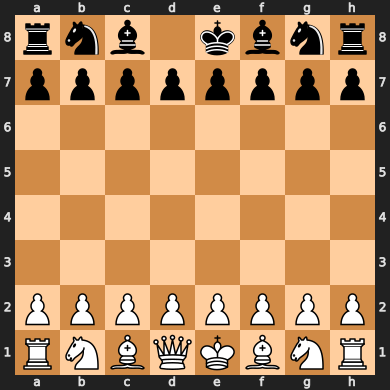

Blancs gagnent (+Reine) : 61.977481842041016


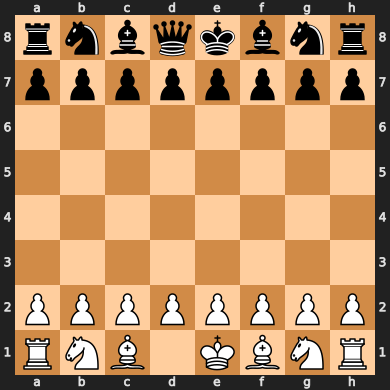

Blancs perdent (-Reine) : -107.77671813964844


In [6]:
# Test 1 : Position de départ
board = chess.Board()
print(f"Départ : {evaluate_board(board, model)}")

# Test 2 : On donne une Reine aux Blancs (Les Noirs perdent leur Reine de d8)
board_win = chess.Board("rnb1kbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1")
display(board_win)
print(f"Blancs gagnent (+Reine) : {evaluate_board(board_win, model)}")


# Test 3 : On donne une Reine aux Noirs (Les Blancs perdent leur Reine de d1)
board_loss = chess.Board("rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNB1KBNR w KQkq - 0 1")
display(board_loss)
print(f"Blancs perdent (-Reine) : {evaluate_board(board_loss, model)}")


# Tests

In [13]:
print("Initialisation du modèle...")
model = ChessNNUE()

# 2. Charger les poids de manière robuste (gestion du '_orig_mod.')
model_path = "../weights/weights4_tuned4/model_weights_4.pth" # REMPLACE PAR LE NOM DE TON FICHIER
try:
    state_dict = torch.load(model_path, map_location=torch.device('cpu'))
    print(state_dict.keys())
    clean_state_dict = {}
    for key, value in state_dict.items():
        clean_key = key.replace("_orig_mod.", "")
        clean_state_dict[clean_key] = value
        
    model.load_state_dict(clean_state_dict)
    print("Poids chargés avec succès !")
except Exception as e:
    print(f"Attention, erreur lors du chargement des poids : {e}")
    print("Le script va continuer avec des poids aléatoires pour le test.")

Initialisation du modèle...
odict_keys(['_orig_mod.linear_stack.0.weight', '_orig_mod.linear_stack.0.bias', '_orig_mod.linear_stack.2.weight', '_orig_mod.linear_stack.2.bias', '_orig_mod.linear_stack.4.weight', '_orig_mod.linear_stack.4.bias', '_orig_mod.linear_stack.6.weight', '_orig_mod.linear_stack.6.bias', '_orig_mod.feature_transformer.weight'])
Poids chargés avec succès !



--- NOUVEAUX TESTS D'ÉVALUATION (DIAGNOSTIC) ---

[Test 1] : 1. Symétrie : Position Initiale depuis les BLANCS
FEN         : rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1
Attendus    : Score de base (vu précédemment à ~11.57)
NNUE Score  : 25.084


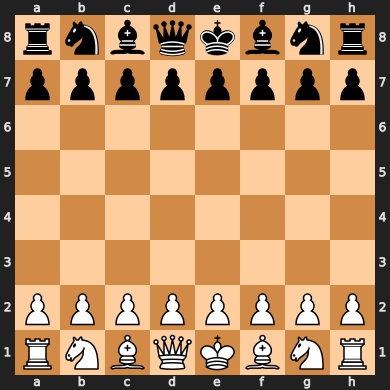


[Test 2] : 2. Symétrie : Position Initiale depuis les NOIRS
FEN         : rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR b KQkq - 0 1
Attendus    : Si le réseau comprend bien qu'avoir le trait rapporte un petit +, on attend ~11.57. Sinon ~ -11.57.
NNUE Score  : 25.084


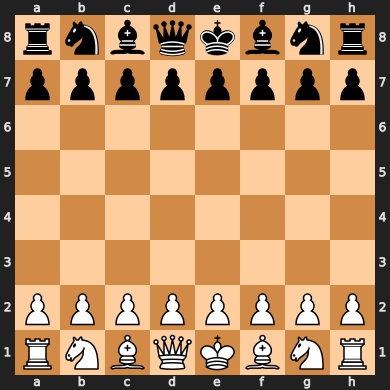


[Test 3] : 3. Échelle pure matérielle : BLANCS ont 1 PION de plus
FEN         : k7/8/8/8/8/8/P7/K7 w - - 0 1
Attendus    : Score positif modéré pour voir la valeur statique d'un pion.
NNUE Score  : 6.504


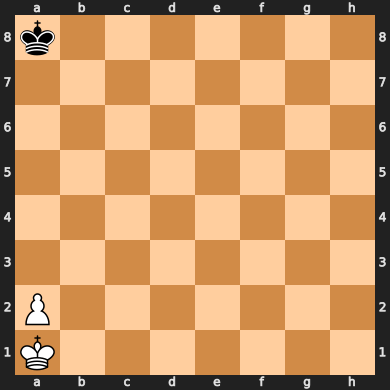


[Test 4] : 4. Échelle pure matérielle : BLANCS ont 1 TOUR de plus
FEN         : k7/8/8/8/8/8/R7/K7 w - - 0 1
Attendus    : Score positif fort pour voir la valeur statique d'une tour (comparé au pion).
NNUE Score  : 9.490


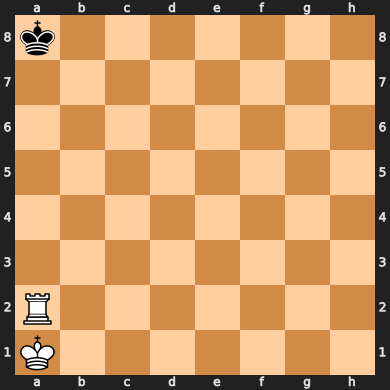


[Test 5] : 5. Test de partialité de l'entraînement (Checkmate imminent tactique mais statiquement égal)
FEN         : k7/R7/8/8/8/8/8/K6r w - - 0 1
Attendus    : Tour blanche et Tour noire présentes. Les noirs menacent mat au prochain coup. Valeur statique pure attendue ~ 0.
NNUE Score  : -13.899


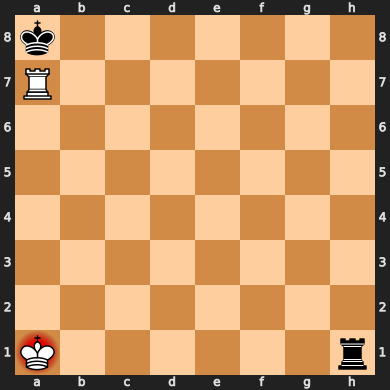


[Test 6] : 6. Évaluation des pions passés / structures bloquées
FEN         : 8/8/8/4p3/4P3/8/8/k3K3 b - - 0 1
Attendus    : Position quasi-nulle ou légère.
NNUE Score  : 3.399


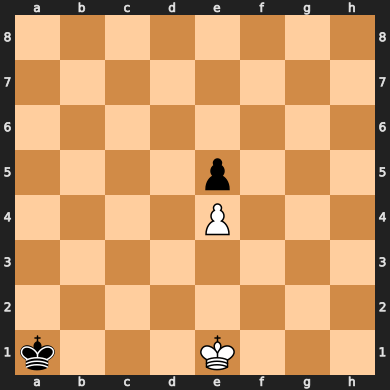


[Test 7] : 7. Position fermée avec avantage positionnel pour les BLANCS
FEN         : rnb1kbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1
Attendus    : Légèrement positif pour les Blancs (avantage positionnel fermé).
NNUE Score  : 880.474


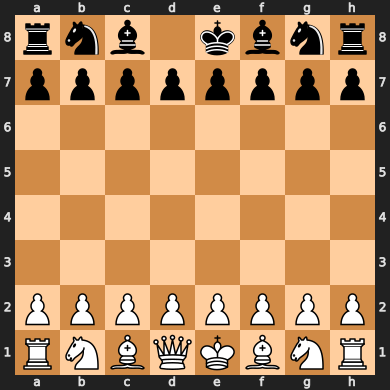

In [14]:
def run_manual_evaluation_tests(model: nn.Module):
    """
    Lance une série de tests d'évaluation manuelle pour diagnostiquer 
    le comportement du réseau NNUE, la symétrie, l'échelle et les finales matérielles.
    """
    print("\n" + "="*50)
    print("--- NOUVEAUX TESTS D'ÉVALUATION (DIAGNOSTIC) ---")
    print("="*50)

    test_positions = [
        {
            "name": "1. Symétrie : Position Initiale depuis les BLANCS",
            "fen": chess.STARTING_FEN,
            "expected": "Score de base (vu précédemment à ~11.57)"
        },
        {
            "name": "2. Symétrie : Position Initiale depuis les NOIRS",
            "fen": "rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR b KQkq - 0 1",
            "expected": "Si le réseau comprend bien qu'avoir le trait rapporte un petit +, on attend ~11.57. Sinon ~ -11.57."
        },
        {
            "name": "3. Échelle pure matérielle : BLANCS ont 1 PION de plus",
            "fen": "k7/8/8/8/8/8/P7/K7 w - - 0 1",
            "expected": "Score positif modéré pour voir la valeur statique d'un pion."
        },
        {
            "name": "4. Échelle pure matérielle : BLANCS ont 1 TOUR de plus",
            "fen": "k7/8/8/8/8/8/R7/K7 w - - 0 1",
            "expected": "Score positif fort pour voir la valeur statique d'une tour (comparé au pion)."
        },
        {
            "name": "5. Test de partialité de l'entraînement (Checkmate imminent tactique mais statiquement égal)",
            "fen": "k7/R7/8/8/8/8/8/K6r w - - 0 1",
            "expected": "Tour blanche et Tour noire présentes. Les noirs menacent mat au prochain coup. Valeur statique pure attendue ~ 0."
        },
        {
            "name": "6. Évaluation des pions passés / structures bloquées",
            "fen": "8/8/8/4p3/4P3/8/8/k3K3 b - - 0 1",
            "expected": "Position quasi-nulle ou légère."
        },
        {
            "name": "7. Position fermée avec avantage positionnel pour les BLANCS",
            "fen": "rnb1kbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1",
            "expected": "Légèrement positif pour les Blancs (avantage positionnel fermé)."
        }
    ]
    
    # {
    #         "name": "Position Initiale",
    #         "fen": chess.STARTING_FEN,
    #         "expected": "Proche de 0.0 (Égalité entre les camps)"
    #     },
    #     {
    #         "name": "Avantage matériel BLANCS (+ Dame)",
    #         "fen": "rnb1kbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1",
    #         "expected": "Fortement POSITIF (ex: > 5.0 ou 500 selon unité)"
    #     },
    #     {
    #         "name": "Avantage matériel NOIRS (- Dame)",
    #         "fen": "rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNB1KBNR w KQkq - 0 1",
    #         "expected": "Fortement NÉGATIF (ex: < -5.0 ou -500)"
    #     },
    #     {
    #         "name": "Checkmate imminent des BLANCS (Mat du couloir)",
    #         "fen": "6k1/5ppp/8/8/8/8/8/R5K1 w - - 0 1",
    #         "expected": "Très fortement POSITIF (Supérieur à l'avantage d'une dame)"
    #     },
    #     {
    #         "name": "Avantage positionnel fermé / Milieu de jeu supérieur BLANC",
    #         "fen": "r1bqkbnr/pppp1ppp/2n5/4p3/4P3/5N2/PPPP1PPP/RNBQKB1R w KQkq - 2 3",
    #         "expected": "Légèrement POSITIF (Avantage blanc de l'ouverture espagnole)"
    #     },
    #     {
    #         "name": "Finale de Rois égale",
    #         "fen": "8/8/4k3/8/8/4K3/8/8 w - - 0 1",
    #         "expected": "Proche de 0.0 (Partie nulle)"
    #     }

    model.eval()
    with torch.no_grad():
        for i, pos_info in enumerate(test_positions, 1):
            board = chess.Board(pos_info["fen"])
            score = evaluate_board(board, model)
            print(f"\n[Test {i}] : {pos_info['name']}")
            print(f"FEN         : {pos_info['fen']}")
            print(f"Attendus    : {pos_info['expected']}")
            print(f"NNUE Score  : {score:.3f}")
            display(board)

    print("\n" + "="*50 + "\n")

run_manual_evaluation_tests(model)


--- NOUVEAUX TESTS D'ÉVALUATION (DIAGNOSTIC) ---

[Test 1] : Base - W
FEN         : rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1
Attendus    :  
NNUE Score  : 25.084


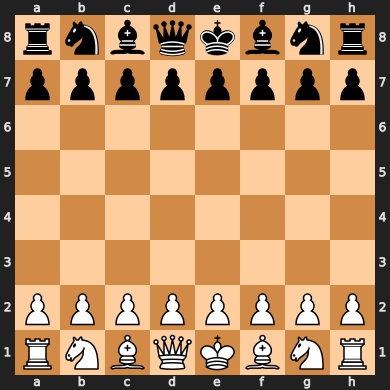


[Test 2] : Dame - W
FEN         : rnb1kbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1
Attendus    :  
NNUE Score  : 880.474


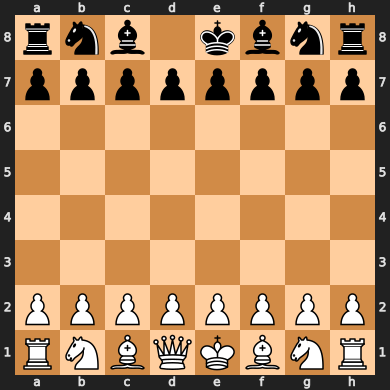


[Test 3] : Fou - W
FEN         : rn1qkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1
Attendus    :  
NNUE Score  : 479.395


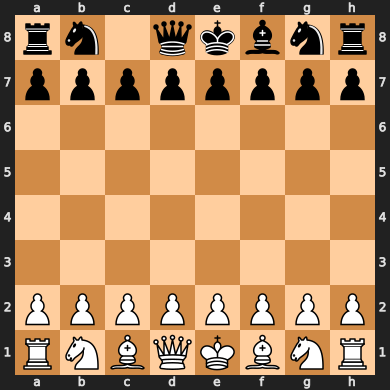


[Test 4] : Cavalier - W
FEN         : r1bqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1
Attendus    :  
NNUE Score  : 386.545


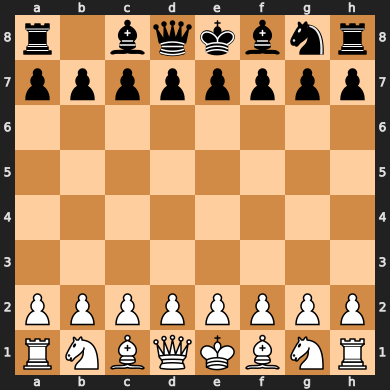


[Test 5] : Tour - W
FEN         : 1nbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1
Attendus    :  
NNUE Score  : 697.760


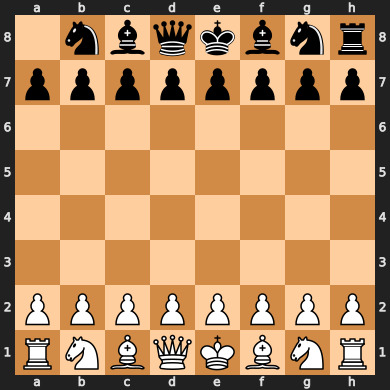


[Test 6] : Pion - W
FEN         : rnbqkbnr/1ppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1
Attendus    :  
NNUE Score  : 151.522


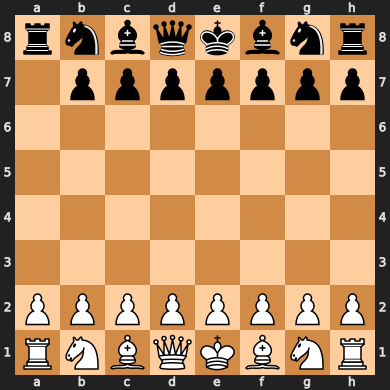


[Test 7] : Base - B
FEN         : rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR b KQkq - 0 1
Attendus    :  
NNUE Score  : 25.084


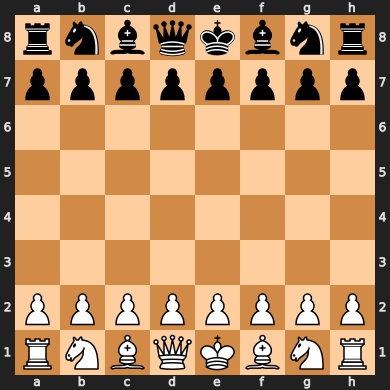


[Test 8] : Dame - B
FEN         : rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNB1KBNR w KQkq - 0 1
Attendus    :  
NNUE Score  : -287.223


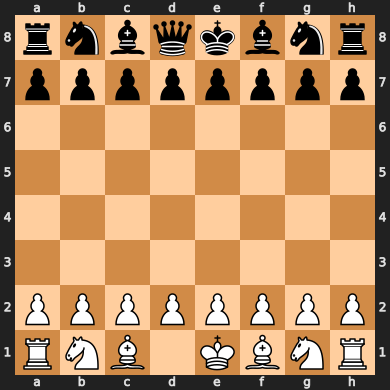


[Test 9] : Fou - B
FEN         : rn1qkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR b KQkq - 0 1
Attendus    :  
NNUE Score  : -187.942


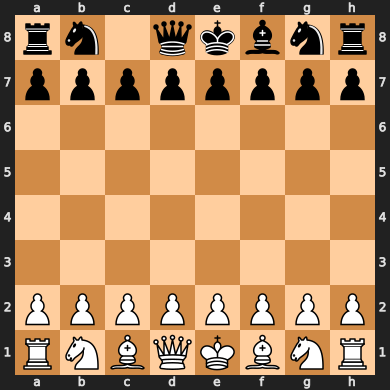


[Test 10] : Cavalier - B
FEN         : r1bqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR b KQkq - 0 1
Attendus    :  
NNUE Score  : -157.663


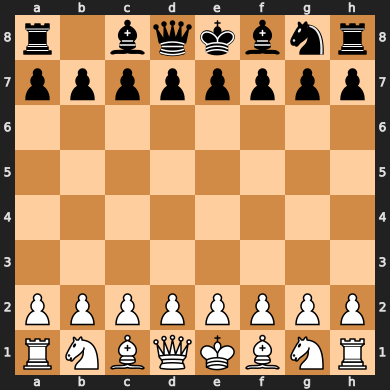


[Test 11] : Tour - B
FEN         : 1nbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR b KQkq - 0 1
Attendus    :  
NNUE Score  : -234.271


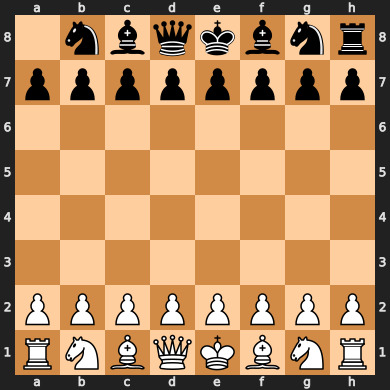


[Test 12] : Pion - B
FEN         : rnbqkbnr/1ppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR b KQkq - 0 1
Attendus    :  
NNUE Score  : -97.854


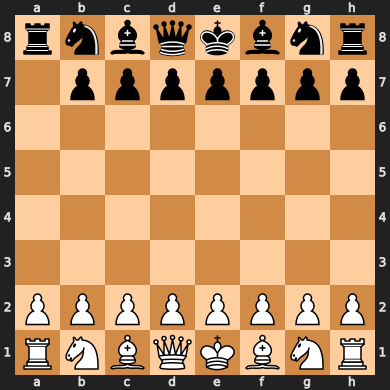

In [15]:
def run_manual_evaluation_tests(model: nn.Module):
    """
    Lance une série de tests d'évaluation manuelle pour diagnostiquer 
    le comportement du réseau NNUE, la symétrie, l'échelle et les finales matérielles.
    """
    print("\n" + "="*50)
    print("--- NOUVEAUX TESTS D'ÉVALUATION (DIAGNOSTIC) ---")
    print("="*50)

# # Base (symétrique, rois roqués)
# r1bq1rk1/pppp1ppp/2n2n2/4p3/4P3/2N2N2/PPPP1PPP/R1BQ1RK1 w - -

# # Retirer la dame noire (avantage dame pour blancs)
# r1b2rk1/pppp1ppp/2n2n2/4p3/4P3/2N2N2/PPPP1PPP/R1BQ1RK1 w - -

# # Retirer la tour noire a8 (avantage tour pour blancs)  
# 2bq1rk1/pppp1ppp/2n2n2/4p3/4P3/2N2N2/PPPP1PPP/R1BQ1RK1 w - -

# # Retirer un pion noir
# r1bq1rk1/1ppp1ppp/2n2n2/4p3/4P3/2N2N2/PPPP1PPP/R1BQ1RK1 w - -

    test_positions = [
        # {
        #     "name": "Base (symétrique, rois roqués)",
        #     "fen": "r1bq1rk1/pppp1ppp/2n2n2/4p3/4P3/2N2N2/PPPP1PPP/R1BQ1RK1 w - - 0 1",
        #     "expected": ""
        # },
        # {
        #     "name": "Retirer la dame noire (avantage dame pour blancs)",
        #     "fen": "r1b2rk1/pppp1ppp/2n2n2/4p3/4P3/2N2N2/PPPP1PPP/R1BQ1RK1 w - - 0 1",
        #     "expected": ""
        # },
        # {
        #     "name": "Retirer la tour noire a8 (avantage tour pour blancs)",
        #     "fen": "2bq1rk1/pppp1ppp/2n2n2/4p3/4P3/2N2N2/PPPP1PPP/R1BQ1RK1 w - - 0 1",
        #     "expected": ""
        # },
        # {
        #     "name": "Retirer un pion noir",
        #     "fen": "r1bq1rk1/1ppp1ppp/2n2n2/4p3/4P3/2N2N2/PPPP1PPP/R1BQ1RK1 w - - 0 1",
        #     "expected": ""
        # }
        {
            "name": "Base - W",
            "fen": "rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1",
            "expected": " "
        },
        {
            "name": "Dame - W",
            "fen": "rnb1kbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1",
            "expected": " "
        },
        {
            "name": "Fou - W",
            "fen": "rn1qkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1",
            "expected": " "
        },
        {
            "name": "Cavalier - W",
            "fen": "r1bqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1",
            "expected": " "
        },
        {
            "name": "Tour - W",
            "fen": "1nbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1",
            "expected": " "
        },
        {
            "name": "Pion - W",
            "fen": "rnbqkbnr/1ppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1",
            "expected": " "
        },
        {
            "name": "Base - B",
            "fen": "rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR b KQkq - 0 1",
            "expected": " "
        },
        {
            "name": "Dame - B",
            "fen": "rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNB1KBNR w KQkq - 0 1",
            "expected": " "
        },
        {
            "name": "Fou - B",
            "fen": "rn1qkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR b KQkq - 0 1",
            "expected": " "
        },
        {
            "name": "Cavalier - B",
            "fen": "r1bqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR b KQkq - 0 1",
            "expected": " "
        },
        {
            "name": "Tour - B",
            "fen": "1nbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR b KQkq - 0 1",
            "expected": " "
        },
        {
            "name": "Pion - B",
            "fen": "rnbqkbnr/1ppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR b KQkq - 0 1",
            "expected": " "
        }
    ]
    
   

    model.eval()
    with torch.no_grad():
        for i, pos_info in enumerate(test_positions, 1):
            board = chess.Board(pos_info["fen"])
            score = evaluate_board(board, model)
            print(f"\n[Test {i}] : {pos_info['name']}")
            print(f"FEN         : {pos_info['fen']}")
            print(f"Attendus    : {pos_info['expected']}")
            print(f"NNUE Score  : {score:.3f}")
            display(board)

    print("\n" + "="*50 + "\n")

run_manual_evaluation_tests(model)

In [8]:
# model = NNUE()
# Charger les poids...

emb = model.feature_transformer.weight  # (40961, 768)

# Indices HalfKP pour dame adverse vs propre dame, roi sur e1 (king_sq=4)
# Dame en d8 (sq=59)
own_queen_idx   = 4 * 640 + 4 * 64 + 59   # 3131  (own)
opp_queen_idx   = 4 * 640 + 9 * 64 + 59   # 3707  (opp)
own_rook_idx    = 4 * 640 + 3 * 64 + 56   # 3128  (own rook a8)
opp_rook_idx    = 4 * 640 + 8 * 64 + 56   # 3640  (opp rook a8)

print("||own_queen||:", emb[own_queen_idx].norm().item())
print("||opp_queen||:", emb[opp_queen_idx].norm().item())
print("||own_rook||:", emb[own_rook_idx].norm().item())
print("||opp_rook||:", emb[opp_rook_idx].norm().item())

# Vérifier aussi la norme moyenne par type de pièce
# for p_name, p_off in [("Pawn",0),("Knight",1),("Bishop",2),("Rook",3),("Queen",4)]:
#     own_norms = []
#     opp_norms = []
#     for ksq in range(64):
#         for sq in range(64):
#             own_idx = ksq * 640 + p_off * 64 + sq
#             opp_idx = ksq * 640 + (p_off + 5) * 64 + sq
#             own_norms.append(emb[own_idx].norm().item())
#             opp_norms.append(emb[opp_idx].norm().item())
#     print(f"{p_name}: own={sum(own_norms)/len(own_norms):.4f}, opp={sum(opp_norms)/len(opp_norms):.4f}")


# Comparer les normes pour king_sq=4 (e1, non-roqué) vs king_sq=6 (g1, roqué)
for p_name, p_off in [("Rook",3), ("Queen",4)]:
    for ksq, ksq_name in [(4, "e1-non-roque"), (6, "g1-roque"), (2, "c1-roque")]:
        norms = [emb[ksq * 640 + p_off * 64 + sq].norm().item() for sq in range(64)]
        print(f"{p_name} | king={ksq_name}: moy={sum(norms)/len(norms):.4f}")

||own_queen||: 1.1956104040145874
||opp_queen||: 0.9776235222816467
||own_rook||: 0.7232145667076111
||opp_rook||: 0.6345340013504028
Rook | king=e1-non-roque: moy=0.7712
Rook | king=g1-roque: moy=0.8793
Rook | king=c1-roque: moy=0.6223
Queen | king=e1-non-roque: moy=1.0785
Queen | king=g1-roque: moy=1.1539
Queen | king=c1-roque: moy=0.9208
